In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from image_util import image_histo
from convert import shift_mountain
from histograms import Luv, Uv
from rotate import rotate_luv


# Target

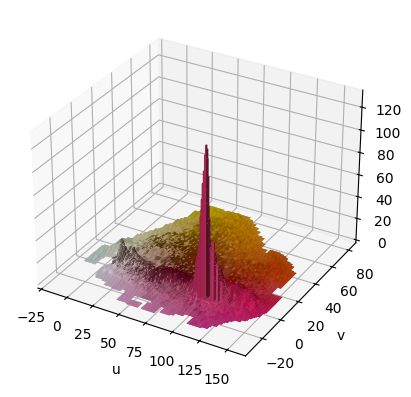

In [6]:
target = Image.open("tape-a.jpg")
# Target is an original stimuli with white background which needs to be removed
target_histo = image_histo(target).without_white(10)

target_smooth = target_histo.collapse_L().smooth()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
target_smooth.plot(ax, target_histo.most_common_Ls())


target primary: Luv(L=37, u=105, v=6) : #aa0e37


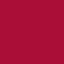

In [7]:
target_mtn = target_smooth.mountains(count=1)[0]
target_luv = target_histo.max_L(Uv(*target_mtn.peak))
target_uv = Uv(target_luv.u, target_luv.v)
print(f"target primary: {target_luv} : {target_luv.hex()}")
target_swatch = Image.new("RGB", (64, 64), target_luv.hex())
display(target_swatch)


# Distractor transforming

26467443.png primary: Luv(L=43, u=100, v=15) : #b63433


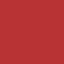

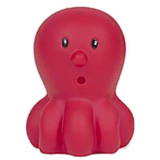

Ajug158.png primary: Luv(L=41, u=133, v=27) : #bf0e00


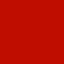

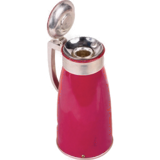

Lamborghini_Diablo.png primary: Luv(L=42, u=131, v=20) : #c30d06


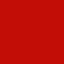

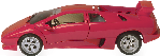

In [8]:
def shift_image(path):
    img = Image.open(path)
    histo = image_histo(img)
    # Example distractors have background removed
    # so `without_white` is not needed
    smooth = histo.collapse_L().smooth()
    mtn = smooth.mountains(count=1)[0]
    luv = histo.max_L(Uv(*mtn.peak))
    print(f"{path} primary: {luv} : {luv.hex()}")
    swatch = Image.new("RGB", (64, 64), luv.hex())
    shifted = shift_mountain(img, mtn, target_uv)[0]
    return swatch, shifted

for p in ["26467443.png", "Ajug158.png", "Lamborghini_Diablo.png"]:
    swatch, shifted = shift_image(p)
    display(swatch, shifted)


# Transforming to rotated color

target rotated 30 degrees: Luv(L=37, u=np.float64(87.93266739736606), v=np.float64(57.696152422706625)) : #963c00


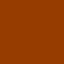

In [12]:
target_30_luv = rotate_luv(target_luv, 30)
target_30_uv = Uv(target_30_luv.u, target_30_luv.v)

target_30_swatch = Image.new("RGB", (64, 64), target_30_luv.hex())
print(f"target rotated 30 degrees: {target_30_luv} : {target_30_luv.hex()}")
display(target_30_swatch)


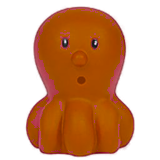

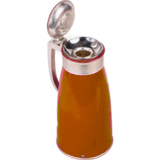

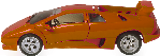

In [13]:
# The same process as `shift_image` above except to the
# `target_30_uv`
def shift_image30(path):
    img = Image.open(path)
    histo = image_histo(img)
    smooth = histo.collapse_L().smooth()
    mtn = smooth.mountains(count=1)[0]
    shifted = shift_mountain(img, mtn, target_30_uv)[0]
    return shifted

for p in ["26467443.png", "Ajug158.png", "Lamborghini_Diablo.png"]:
    shifted = shift_image30(p)
    display(shifted)
